# Figure S9. UHGV annotation consistency within clusters

In [4]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [ ]:
### Download metadata
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/votus_metadata_extended.tsv

In [10]:
### filter UHGV metadata to HQ viruses
hq_votus_pre = (
    pl.read_csv('votus_metadata_extended.tsv', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'uhgv_taxonomy', 'class_name', 'order_name', 'family_name', 'genus_name', 'host_lineage_gtdb_r207', 'crispr_host_lineage_gtdb_r207', 'kmers_host_lineage_gtdb_r207', 'host_prediction_method', 'lifestyle', 'lifestyle_evidence'])

        .rename({'class_name':'Class', 'order_name':'Order', 'family_name':'Family', 'genus_name':'Genus'})
        .with_columns([
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Species'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Genus'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Family'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Order'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Class'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Phylum'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vOTU-')).then(pl.col('uhgv_taxonomy').str.split(';vOTU-').list[-1]).otherwise(pl.lit(None)).alias('virus_species'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBGEN-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBGEN-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subgenus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vGENUS-')).then(pl.col('uhgv_taxonomy').str.split(';vGENUS-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_genus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBFAM-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subfamily'),
            pl.when(pl.col('uhgv_taxonomy').str.contains('vFAM-')).then(pl.col('uhgv_taxonomy').str.split('vßFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_family'),
        ])
)

hq_votus = (
    pl.read_csv('../figure_1/uhgv_metadata.tsv', separator='\t', ignore_errors=True)[['uhgv_genome', 'uhgv_votu', 'checkv_completeness', 'checkv_completeness_method', 'viral_confidence']]
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .rename({'uhgv_votu': 'virus_species'})
        .with_columns([
            pl.col('virus_species').str.replace('vOTU-', '')
        ])
        .join(hq_votus_pre, on='virus_species', how='left')
)

complete_genomes = set(
    hq_votus
        .filter(pl.col('checkv_completeness_method').str.contains('TR'))
        ['uhgv_genome']
)

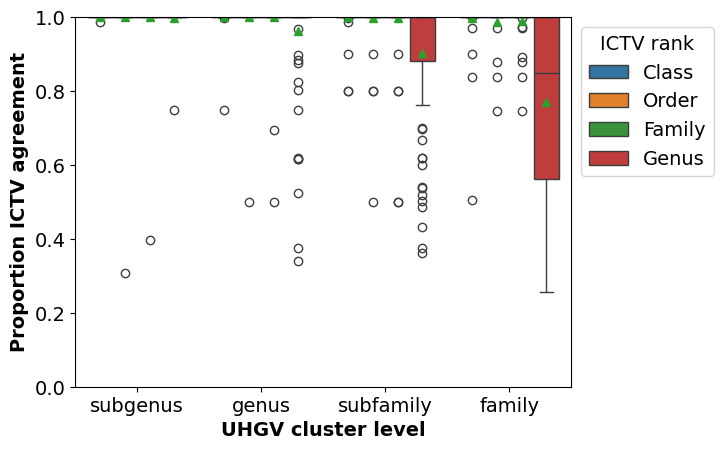

In [17]:
### ICTV taxonomy consistency within UHGV subgenus-family clusters
ictv_stats_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    for ictv_level in ['Class', 'Order', 'Family', 'Genus']:
        ictv_stats_lst.append(
            hq_votus
                .filter(pl.col(ictv_level) != 'NULL')
                .group_by([f'{ictv_level}', f'virus_{virus_level}'])
                .agg([
                    pl.len().alias('ictv_taxa_count')
                ])
                .group_by(f'virus_{virus_level}')
                .agg([
                    pl.col('ictv_taxa_count').sum().alias('virus_total'),
                    pl.col('ictv_taxa_count').max().alias('virus_max_ictv_count')
                ])
                .filter(pl.col('virus_total') >= 3)
                .with_columns([
                    (pl.col('virus_max_ictv_count') / pl.col('virus_total')).alias('ictv_agreement'),
                    pl.lit(ictv_level).alias('ictv_level'),
                    pl.lit(virus_level).alias('virus_level')
                ])
                .rename({'ictv_level':'ICTV rank'})
                [['ictv_agreement', 'ICTV rank', 'virus_level']]
        )

plot_df = pl.concat(ictv_stats_lst)

# create boxplot of ictv agreement
sns.boxplot(data=plot_df.to_pandas(), y='ictv_agreement', x='virus_level', hue='ICTV rank', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Proportion ICTV agreement', fontdict={'fontweight': 'bold'})
plt.xlabel('UHGV cluster level', fontdict={'fontweight': 'bold'})
# move legend outside of plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.legend(title='ICTV rank', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

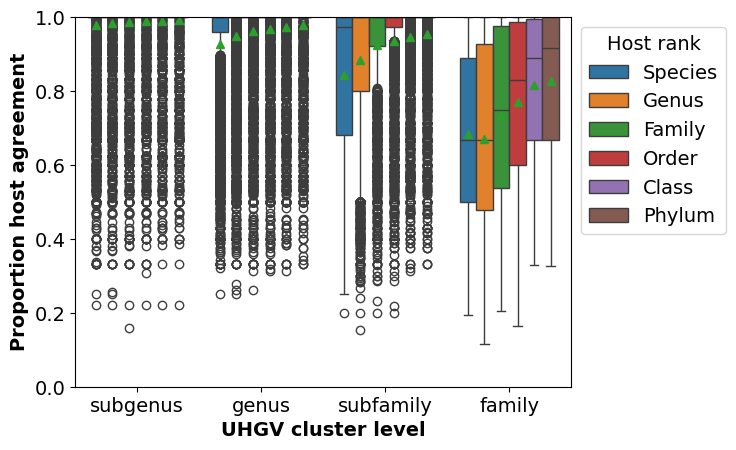

In [18]:
### Host taxonomy consistency within UHGV clusters
host_stats_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    for host_level in ['Species', 'Genus', 'Family', 'Order', 'Class', 'Phylum']:
        host_stats_lst.append(
            hq_votus
                .group_by([f'host_{host_level}', f'virus_{virus_level}'])
                .agg([
                    pl.len().alias('host_taxa_count')
                ])
                .group_by(f'virus_{virus_level}')
                .agg([
                    pl.col('host_taxa_count').sum().alias('virus_total'),
                    pl.col('host_taxa_count').max().alias('virus_max_host_count')
                ])
                .filter(pl.col('virus_total') >= 3)
                .with_columns([
                    (pl.col('virus_max_host_count') / pl.col('virus_total')).alias('host_agreement'),
                    pl.lit(host_level).alias('host_level'),
                    pl.lit(virus_level).alias('virus_level')
                ])
                [['host_agreement', 'host_level', 'virus_level']]
                .rename({'host_level':'Host rank'})
        )

plot_df = pl.concat(host_stats_lst)

# create boxplot of host phylum agreement
sns.boxplot(data=plot_df.to_pandas(), y='host_agreement', x='virus_level', hue='Host rank', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Proportion host agreement', fontdict={'fontweight': 'bold'})
plt.xlabel('UHGV cluster level', fontdict={'fontweight': 'bold'})
# move legend outside of plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# add legend title
plt.legend(title='Host rank', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

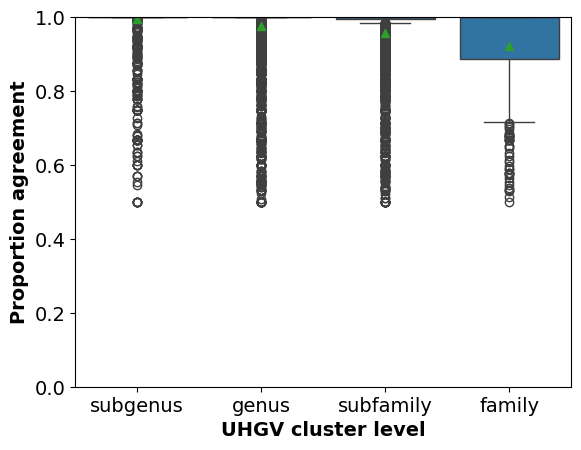

In [19]:
### Lifestyle consistency within clusters
lifestyle_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    lifestyle_lst.append(
        hq_votus
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

plot_df = pl.concat(lifestyle_lst)

# create boxplot of host phylum agreement
ax = sns.boxplot(data=plot_df.to_pandas(), y='lifestyle_agreement', x='virus_level', showmeans=True)

plt.ylim(0,1)
plt.ylabel('Proportion agreement', fontdict={'fontweight': 'bold'})
plt.xlabel('UHGV cluster level', fontdict={'fontweight': 'bold'})
plt.show()

In [21]:
### Protein clusters shared by all members of UHGV clusters
protein_clusters = (
    pl.read_csv('cluster_membership.tsv.gz', separator='\t', ignore_errors=True, columns=['cluster_name', 'cluster_member'])
        .with_columns([pl.col('cluster_member').str.split('_').list[0].alias('uhgv_genome')])
)

protein_clusters_meta = protein_clusters.join(hq_votus.select(['uhgv_genome', 'virus_species', 'virus_subgenus', 'virus_genus', 'virus_subfamily', 'virus_family']), on='uhgv_genome', how='inner')

/tmp/ipykernel_68581/3793627691.py:26: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_pcs')


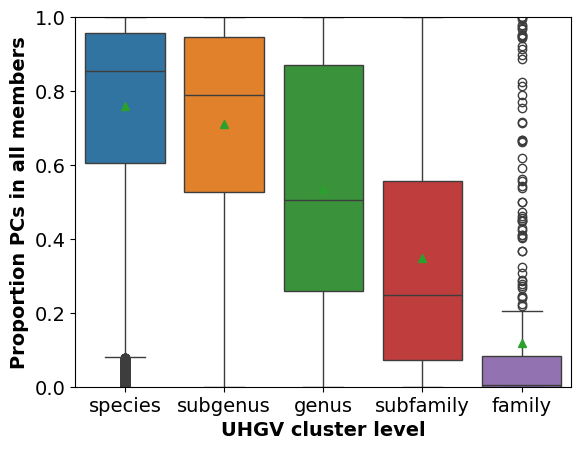

In [23]:
### Proportion of PCs in UHGV clusters shared by all members
pc_stats_lst = []

for virus_level in ['species', 'subgenus', 'genus', 'subfamily', 'family']:
    uhgv_species_per_cluster = (
        hq_votus
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.len().alias('uhgv_species_in_cluster')
            ])
            .filter(pl.col('uhgv_species_in_cluster') >= 2)
    )
    uhgv_prop_pcs_shared_by_all = (
        protein_clusters_meta
            .group_by([f'virus_{virus_level}', 'cluster_name'])
            .agg([
                pl.len().alias('cluster_member_count')
            ])
            .join(uhgv_species_per_cluster, on=f'virus_{virus_level}', how='inner')
            .with_columns([
                (pl.col('cluster_member_count') == pl.col('uhgv_species_in_cluster')).alias('pcs_shared_by_all')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('pcs_shared_by_all').sum().alias('number_pcs_shared_by_all'),
                pl.len().alias('total_pcs')
            ])
            .with_columns([
                (pl.col('number_pcs_shared_by_all') / pl.col('total_pcs')).alias('prop_pcs_shared_by_all'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['virus_level', 'prop_pcs_shared_by_all']]
    )
    pc_stats_lst.append(
        uhgv_prop_pcs_shared_by_all
    )

plot_df = pl.concat(pc_stats_lst)

# create boxplot of host phylum agreement
sns.boxplot(data=plot_df.to_pandas(), y='prop_pcs_shared_by_all', x='virus_level', hue='virus_level', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Proportion PCs in all members', fontdict={'fontweight': 'bold'})
plt.xlabel('UHGV cluster level', fontdict={'fontweight': 'bold'})
plt.show()